Cross-sectional Momentum with Trend Overlay
===========================================

This notebook backtests a strategy that selects assets based on 30-day cumulative returns
from a liquid universe, with a Bitcoin EMA trend filter to manage market beta.

Ideas
-----

- [ ] MDC instead of EMA as trend filter

In [1]:
days_momentum = "14"
days_holding = "10"
n_buckets = "4"
ema_fast = "5"
ema_slow = "100"
volume_cutoff = "10_100_000"
start_date = "2020-01-01"

In [2]:
import polars as pl
import numpy as np
import datetime as dt
import scrapbook as sb
import backtest as bt

days_momentum_P = int(days_momentum)
days_holding_P = int(days_holding)
n_buckets_P = int(n_buckets)
ema_fast_P = int(ema_fast)
ema_slow_P = int(ema_slow)
volume_cutoff_P = float(volume_cutoff)
start_date_P = dt.datetime.strptime(start_date, "%Y-%m-%d").replace(tzinfo=dt.timezone.utc)

assert days_momentum_P > 0, "Lookback must be positive"
assert days_holding_P > 0, "Holding period must be positive"
assert n_buckets_P > 1, "Must have at least 2 buckets for cross-sectional ranking"
assert ema_fast_P < ema_slow_P, "Fast EMA must be smaller than Slow EMA"

print(
    f"""
Running backtest with: Lookback={days_momentum_P}, Rebalance={days_holding_P}d, Buckets={n_buckets_P}"
Liquidity Filter: ${volume_cutoff_P:,.0f} consistent volume")
Trend Overlay: BTC EMA({ema_fast_P}/{ema_slow_P})
"""
)


Running backtest with: Lookback=14, Rebalance=10d, Buckets=4"
Liquidity Filter: $10,100,000 consistent volume")
Trend Overlay: BTC EMA(5/100)



In [3]:
# Load Binance USDT daily data
df = (
    pl.read_parquet("stables-1d.parquet")
    .sort(["symbol", "ts"])
    .with_columns(pl.col("ts").dt.cast_time_unit("us"))
)

# Calculate Features BEFORE filtering (allows for EMA/Momentum warm-up)
df = df.with_columns(
    [
        # Cumulative return for momentum ranking [6]
        (pl.col("close").pct_change(days_momentum_P).over("symbol")).alias("momentum_score"),
        # 30-day Volume Consistency Filter
        (pl.col("quote_volume") >= volume_cutoff_P)
        .cast(pl.Int32)
        .rolling_mean(window_size=30)
        .over("symbol")
        .alias("liquidity_pass"),
    ]
)

# Generate Bitcoin Trend Overlay Signal [5]
btc_prices = df.filter(pl.col("symbol") == "BTCUSDT").select(["ts", "close"])
btc_trend = (
    btc_prices.with_columns(
        [
            pl.col("close").ewm_mean(span=ema_fast_P).alias("ema_f"),
            pl.col("close").ewm_mean(span=ema_slow_P).alias("ema_s"),
        ]
    )
    .with_columns(
        (pl.col("ema_f") > pl.col("ema_s")).cast(pl.Int32).alias("trend_signal")
    )
    .select(["ts", "trend_signal"])
)

# Join trend signal back to main dataframe
df = df.join(btc_trend, on="ts", how="left")

# Now filter by start date for the backtest
df = df.filter(pl.col("ts") >= start_date_P)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2298/2298 [00:25<00:00, 91.23it/s]


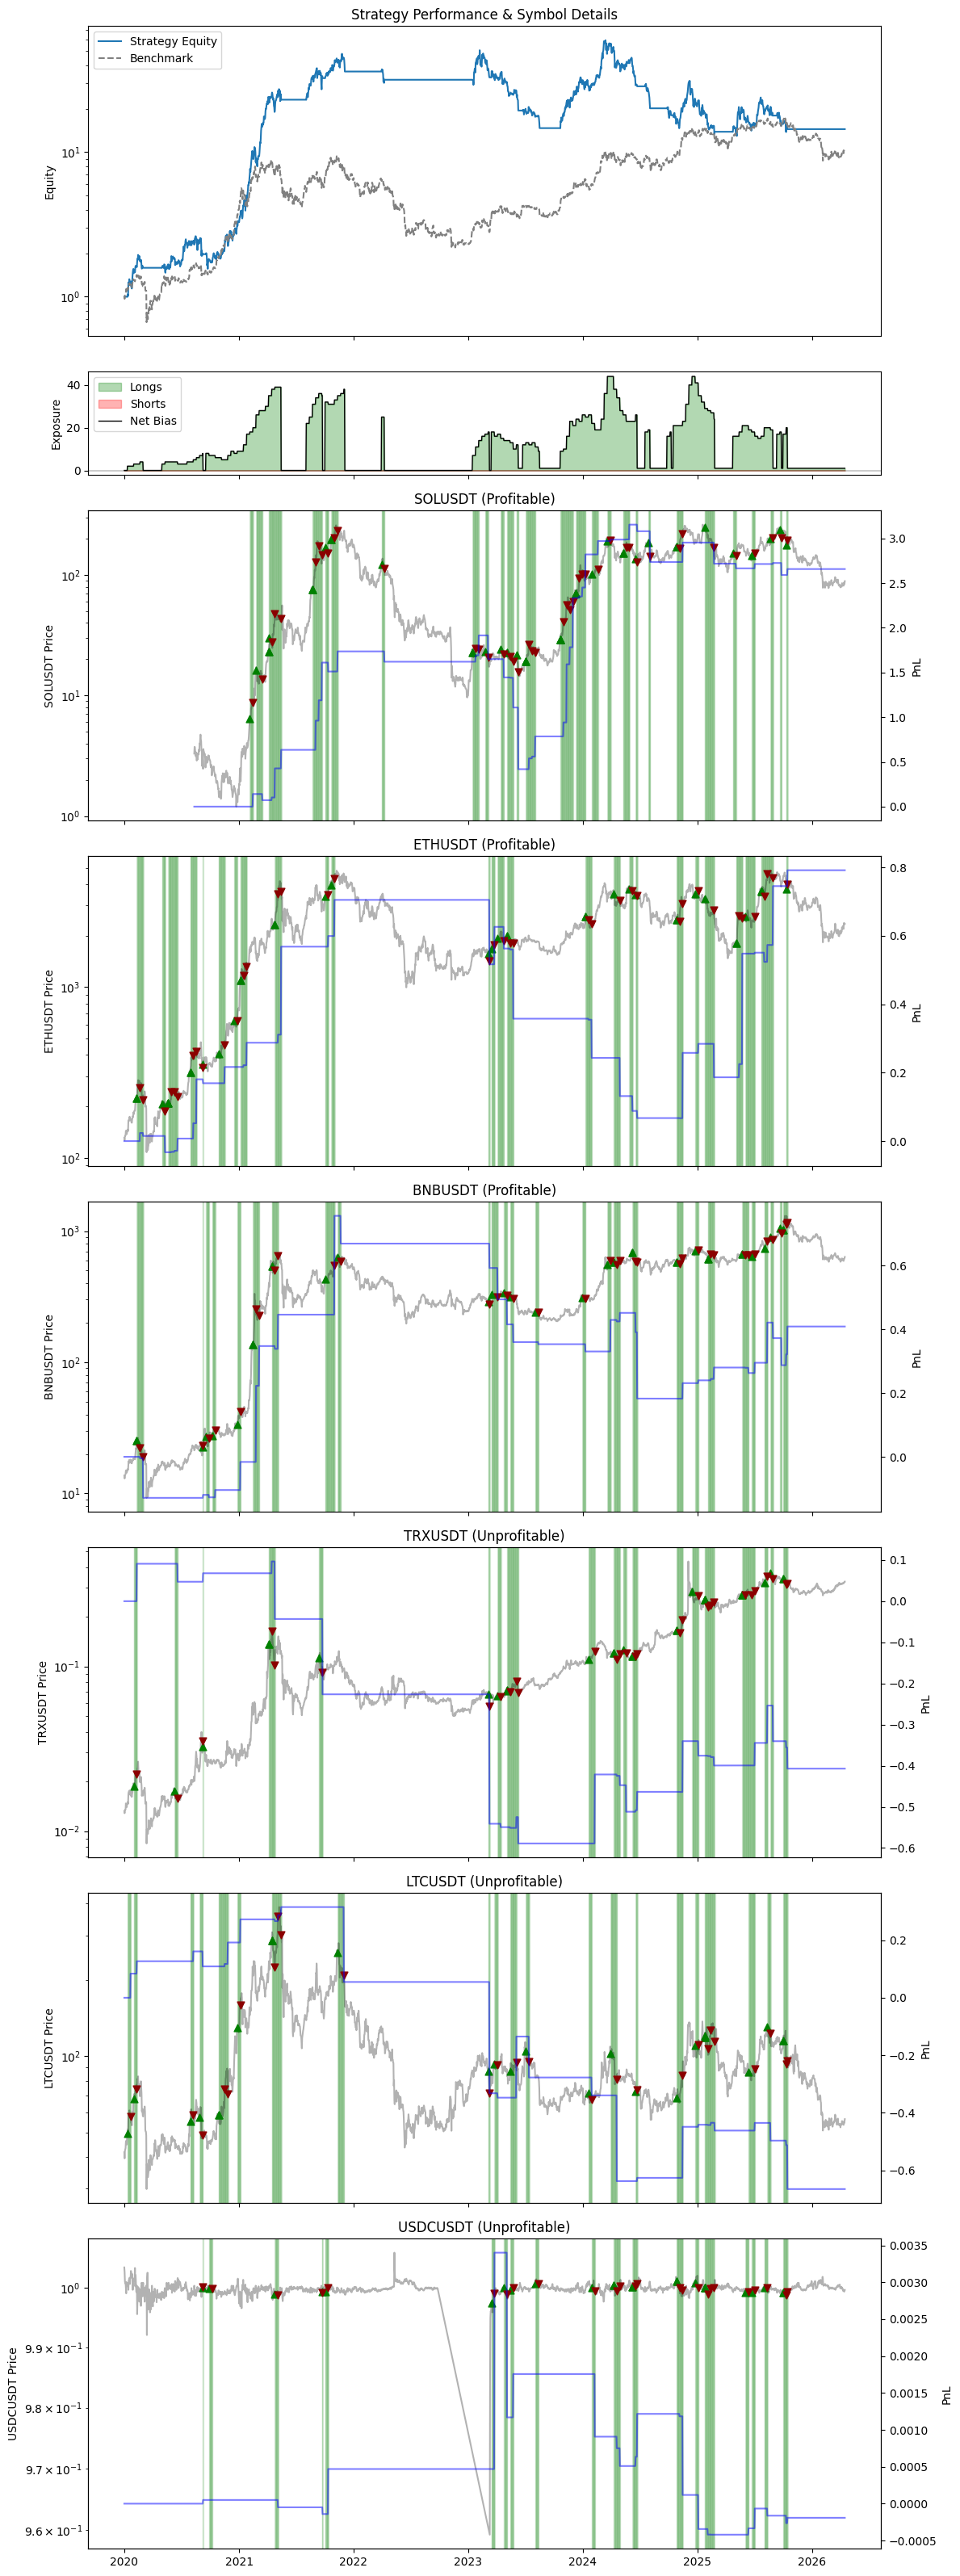

In [4]:
class CsMomentumAlpha(bt.AlphaModel):
    def __init__(self, n_buckets, volume_cutoff):
        self.n_buckets = n_buckets
        self.volume_cutoff = volume_cutoff

    def __call__(self, df: pl.DataFrame) -> list[bt.Signal]:
        today = df["ts"].max()
        dfnow = df.filter(pl.col("ts") == today)

        if dfnow.is_empty():
            return []

        # If trend is down, no signals (liquidate/stay in cash)
        # trend_signal is joined to all symbols, so we can just check the first row
        if dfnow["trend_signal"][0] == 0:
            return []

        candidates = dfnow.filter(
            (pl.col("liquidity_pass") >= 0.5)
            & (pl.col("momentum_score").is_not_null())
            & (pl.col("momentum_score").is_finite())
        )

        if candidates.is_empty():
            return []

        ranked = candidates.with_columns(
            pl.col("momentum_score")
            .rank("dense")
            .qcut(self.n_buckets, labels=[str(i) for i in range(self.n_buckets)])
            .alias("bucket")
        )

        winner_bucket = str(self.n_buckets - 1)
        winners = ranked.filter(pl.col("bucket") == winner_bucket)

        return [
            bt.Signal(row["symbol"], True, 1.0) for row in winners.iter_rows(named=True)
        ]


class TrendExit(bt.RiskModel):
    def __call__(self, df: pl.DataFrame, folio: list[bt.Position]) -> list[bt.Order]:
        if not folio:
            return []
        today = df["ts"].max()
        day_data = df.filter(pl.col("ts") == today)
        if day_data.is_empty():
            return []
        trend = day_data["trend_signal"][0]
        if trend == 0:
            return [bt.Order(pos.symbol, -pos.shares) for pos in folio]
        return []


test = bt.Backtest(
    df,
    alpha=CsMomentumAlpha(n_buckets_P, volume_cutoff_P),
    portfolio=bt.EqualWeight(),
    risk=TrendExit(),
    period=days_holding_P,
    benchmark="BTCUSDT",
)

test.run()
res = test.report(plot=True)

In [5]:
for col in set(res.columns) - {"year", "src"}:
    s = res.filter(pl.col("src") == "Strategy")
    b = res.filter(pl.col("src") == "Benchmark")

    val = s[col].mean() if not s.is_empty() else None
    bench_val = b[col].mean() if not b.is_empty() else None

    # Handle NaN/Inf for JSON compliance in sb.glue by converting to null (None)
    if val is not None and (np.isnan(val) or np.isinf(val)):
        val = None

    print(f"{col}: {val} ({bench_val})")
    sb.glue(col, float(val) if val is not None else None)

cagr: 1.6513088122503015 (0.7287423882011073)


fees: 1.1224503820787177 (None)


ir: 0.04420003531925291 (None)


ann_std: 0.4624772022977294 (0.49356767683914454)


sortino: 1.0803262296469291 (1.2092504369040438)


...

mae: -0.15083118467912845 (None)


sharpe: 0.5895320361801876 (0.6469625207991567)


ann_return: 0.4042213285677204 (0.32489750185314437)


maxdd: -0.39786665446975 (-0.40994200324666735)


win_rate: 0.4472892137195122 (None)
